# Physique des marchés
## TP3.1 : Jeu de la minorité avec nombre variable d’agents

### Par : Adonis JAMAL

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau
import matplotlib.pyplot as plt
from numba import njit
from tqdm import tqdm

np.random.seed(18)

---
Le modèle le plus simple est défini de la façon suivante : 
- $N_{s}$ spéculateurs possèdent chacun une stratégie $a_{i}^{\mu}\in\{-1,+1\}$, $i=1,\dots,N_{s}$, $\mu=1,\dots,P$.
- On ajoute de la prévisibilité à la main, en supposant que $N_{p}$ autres agents utilisent leur stratégie à chaque pas de temps. De façon équivalente, on peut considérer une contribution des producteurs constante pour un état $\mu$ donné, que l'on dénote $\Omega^{\mu}$. On peut tirer $\Omega^{\mu}$ à partir d'une distribution $\mathcal{N}(0,N_{p})$.
- La stratégie du spéculateur $i$ est testée en temps réel et sa performance cumulée est assignée à un scalaire : $$U_{i}(t+1) = U_{i}(t) - a_{i}^{\mu(t)}A(t) - \epsilon, \quad (1)$$ où $A(t) = \Omega^{\mu(t)} + \sum_{i=1}^{N_{s}}n_{i}(t)a_{i}^{\mu(t)}$, $n_{i} = \Theta[U_{i}(t)]$ contrôle la participation de l'agent $i$ au jeu, $\Theta$ est la fonction de Heaviside, et $\epsilon$ est la performance minimale attendue de la stratégie pour que l'agent $i$ la considère comme suffisamment performante et l'utilise.
- La dynamique de $\mu$ peut être considérée ou comme totalement aléatoire ou comme un encodage des derniers $M$ signes de $A(t)$ : dans ce cas, sa dynamique est donnée par $$\mu_{t+1} = (2\mu_{t}) \bmod 2^{M} + \Theta[A(t)]$$

Indications :
1. On notera que l'équation (1) peut être écrite sous forme vectorielle. En particulier, $a_{i}^{\mu}\equiv a_{i,\mu}$, une matrice d'éléments aléatoires -1 et +1.
2. L'état stationnaire du système est atteint après environ $200P/\epsilon$. Effectuer les moyennes sur les $200P/\epsilon$ itérations suivantes.
3. Moyenner les mesurables sur au moins 100 réalisations de $200P/\epsilon$ chacune.
4. Il est toujours difficile d'explorer l'espace des paramètres. Étudier le cas $\epsilon=0.01$, $P\in[10,20]$ et $n_{p}=N_{p}/P=1$.


---
1. Programmer efficacement ce modèle dans le langage de votre choix.

In [2]:
@njit
def _run_simulation(a, Omega, U, mu, P, epsilon, T):
    """Core simulation loop (numba-accelerated)."""
    A_history = np.empty(T)
    mu_history = np.empty(T, dtype=np.int64)
    for t in range(T):
        n = (U >= 0).astype(np.float64)
        A_t = Omega[mu] + np.sum(n * a[:, mu])
        A_history[t] = A_t
        mu_history[t] = mu
        U -= a[:, mu] * A_t + epsilon
        mu = (2 * mu + int(A_t > 0)) % P
    return A_history, mu_history, U, mu

def simulate_minority_game(N_s, P, N_p, epsilon, T):
    Omega = np.random.normal(0, np.sqrt(N_p), size=P)
    a = np.random.choice([-1, 1], size=(N_s, P)).astype(np.float64)
    U = np.zeros(N_s)
    mu = np.random.randint(0, P)
    A_history, mu_history, U, mu = _run_simulation(a, Omega, U, mu, P, epsilon, T)
    return A_history, mu_history, Omega

def measure_observables(N_s, P, N_p, epsilon, n_realizations=100):
    """Run transient + measurement phase and return averaged sigma^2 and H_0."""
    T_phase = int(200 * P / epsilon)
    sigma2_list = np.zeros(n_realizations)
    H0_list = np.zeros(n_realizations)
    
    for r in range(n_realizations):
        Omega = np.random.normal(0, np.sqrt(N_p), size=P)
        a = np.random.choice([-1, 1], size=(N_s, P)).astype(np.float64)
        U = np.zeros(N_s)
        mu = np.random.randint(0, P)
        
        # Transient
        _, _, U, mu = _run_simulation(a, Omega, U, mu, P, epsilon, T_phase)
        
        # Measurement
        A_meas, mu_meas, U, mu = _run_simulation(a, Omega, U, mu, P, epsilon, T_phase)
        
        sigma2_list[r] = np.mean(A_meas**2)
        
        # Conditional mean <A|mu> for each state
        H0 = 0.0
        for s in range(P):
            mask = (mu_meas == s)
            if np.any(mask):
                H0 += np.mean(A_meas[mask])**2
        H0_list[r] = H0 / P
    
    return np.mean(sigma2_list), np.mean(H0_list)

---
2. Vérifier que l'amplitude de $A(t)$ explose au cours du temps si le nombre de spéculateurs est suffisamment grand, à $P$ et $N_{p}$ fixes, en traçant $A(t)$ en fonction de $t$.

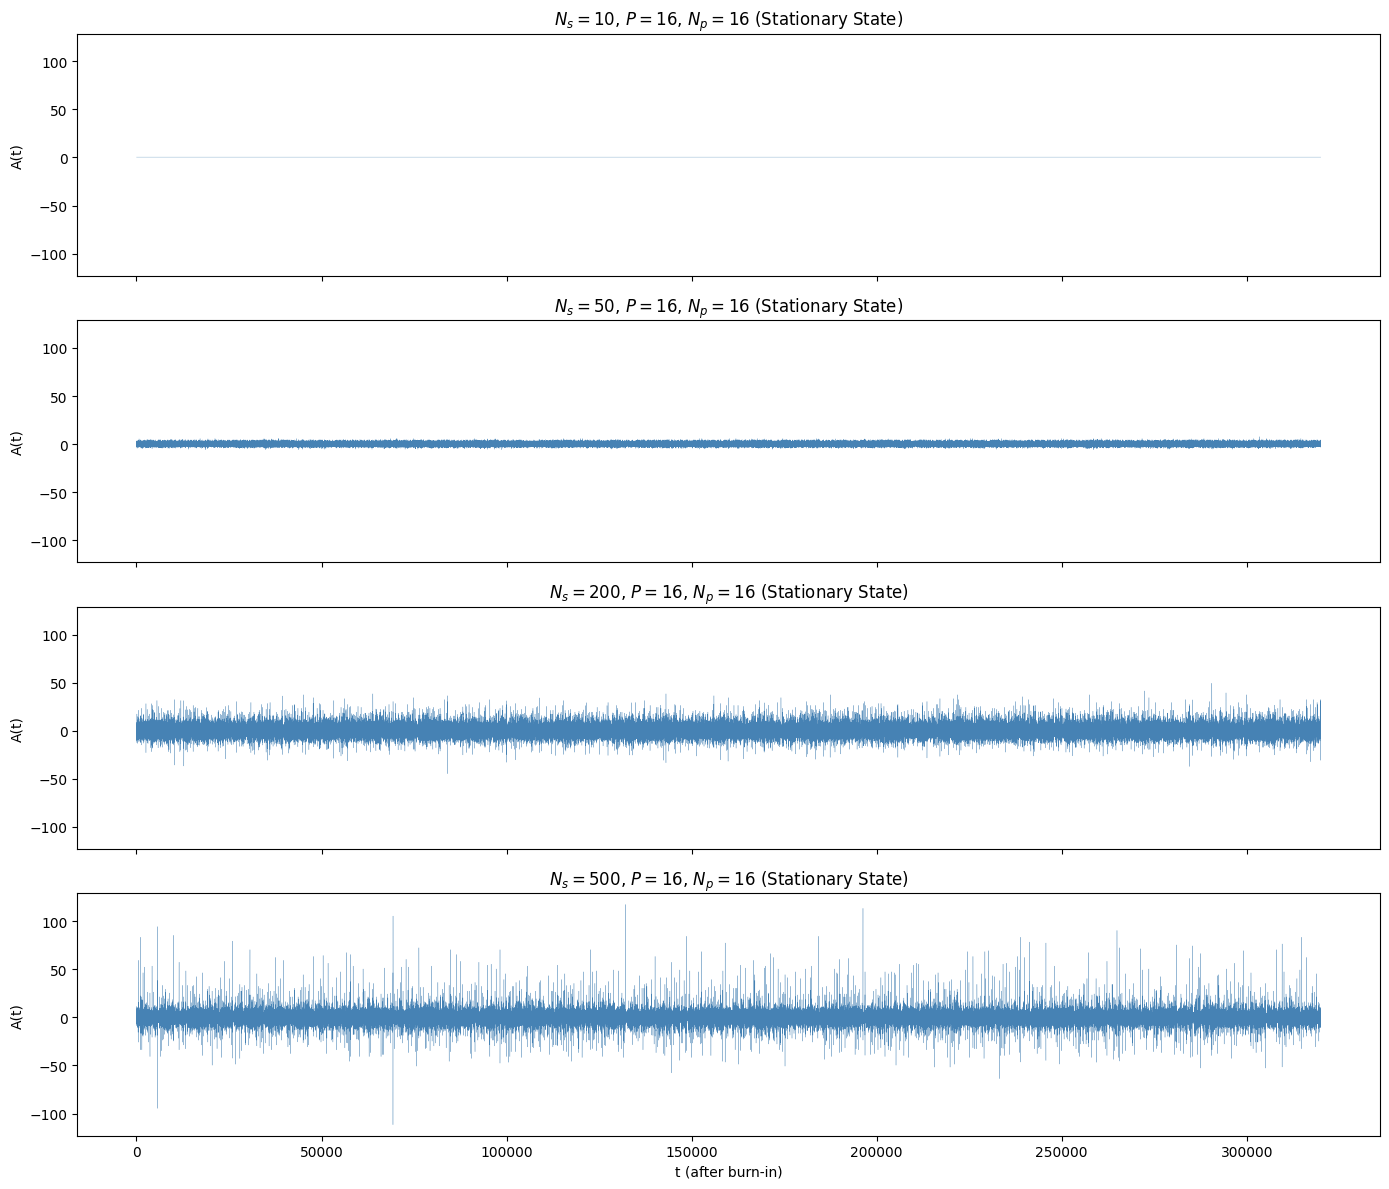

In [3]:
# Parameters
P = 16
N_p = P
epsilon = 0.01
T = int(400 * P / epsilon)
burn_in = int(200 * P / epsilon) # Ignore transient phase
N_s_values = [10, 50, 200, 500]

fig, axes = plt.subplots(len(N_s_values), 1, figsize=(14, 3 * len(N_s_values)), sharex=True, sharey=True)

for idx, N_s in enumerate(N_s_values):
    A_history, _, _ = simulate_minority_game(N_s, P, N_p, epsilon, T)
    axes[idx].plot(A_history[burn_in:], linewidth=0.2, color='steelblue')
    axes[idx].set_ylabel('A(t)')
    axes[idx].set_title(f'$N_s = {N_s}$, $P = {P}$, $N_p = {N_p}$ (Stationary State)')

axes[-1].set_xlabel('t (after burn-in)')
plt.tight_layout()
plt.show()

<blockquote>

For small values, $N_s = \{50, 200\}$, the speculators are easily absorbed by the market. Because the number of strategies is small relative to the complexity of the market ($P=16$), they can find and exploit predictability without crowding each other out. The aggregate action $A(t)$ remains relatively stable.

For large values, $N_s = \{500\}$, we observe massive, intermittent spikes in volatility (endogenous fluctuations). As the number of speculators grows, the market becomes crowded. The agents effectively eliminate the available predictability. Once the predictability vanishes, agents with similar strategies crowd into the same actions, causing massive price impacts (the spikes) before their scores drop and they temporarily exit the market.

For $N_s=10$, we observe a straight line with a small positive value of $A(t)$. This is highly unusual, and we attempt to explain it as follows:

The market state $\mu$ updates by shifting in the sign of $A(t)$. For $P=16$, the rule is $$\mu_{t+1} = (2\mu_{t} + \Theta[A(t)]) \bmod 16$$

If the sign of $A(t)$ is consistently positive for several turns, the state is trapped at $\mu=15$. If it is consistently negative, the state becomes $\mu=0$.

For the system to escape state $15$, the speculators must produce a negative $A(t)$. But due to $A(t) = \Omega^{\mu} + \sum n_i a_{i}^{15}$, with $N_p=16$, the producer bias $\Omega$ is drawn from $\mathcal{N}(0,16)$. If $\Omega^{15}$ happens to be large and positive, the $N_s=10$ agents might not have enough combined weight to overpower the producers and push $A(t)$ negative.

Since the agents lack the capital to flip the sign of $A(t)$, the state never leaves $\mu=15$. The agents who happen to have a strategy opposing $A(t)$ will make a steady profit, their scores $U_i$ will grow continuously, and they will play forever. The others will go bankrupt and permanently exit the market. The active pool becomes static, and $A(t)$ remains constant at a positive value.

</blockquote>

---
3. Mesurer les fluctuations $\sigma^{2}=\langle A^{2}\rangle$ et la prévisibilité $H_{0}=\sum_{\mu}\langle A|\mu\rangle^{2}/P$.Tracer $\sigma^{2}/P$ et $H_{0}/P$ en fonction de $n_{s}=N_{s}/P$ en fixant $P$ et en faisant varier $N_{s}$ (10-15 points suffisent). La moyenne est prise sur plusieurs réalisations du jeu pour chaque jeu de paramètres.

Scanning N_s: 100%|██████████| 12/12 [12:19<00:00, 61.64s/it] 


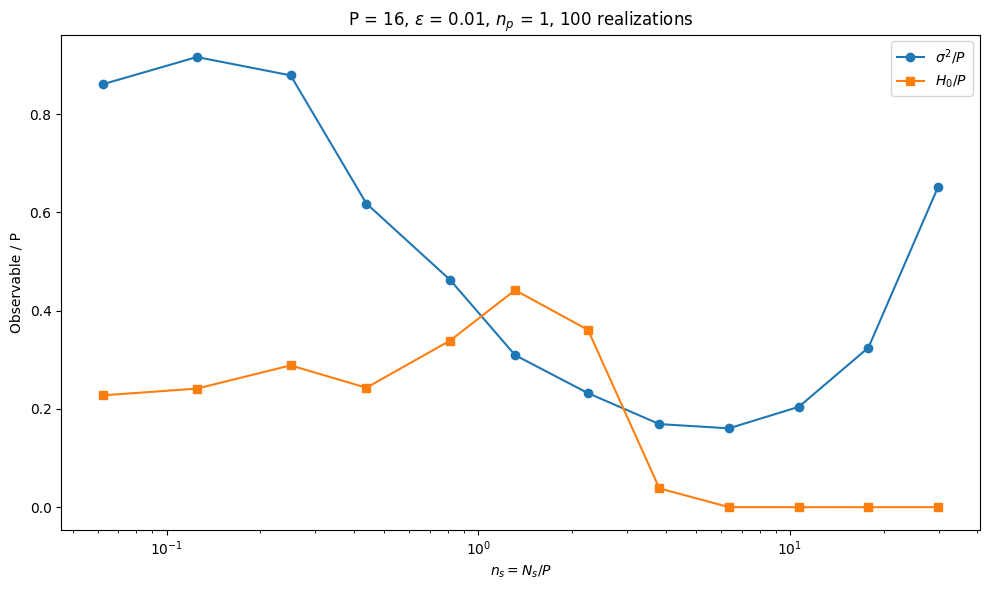

In [4]:
# Parameters
P = 16
N_p = P
epsilon = 0.01
n_realizations = 100

N_s_values = np.unique(np.logspace(np.log10(1), np.log10(30 * P), 13).astype(int))
n_s_values = N_s_values / P

sigma2_arr = np.zeros(len(N_s_values))
H0_arr = np.zeros(len(N_s_values))

for i, N_s in enumerate(tqdm(N_s_values, desc="Scanning N_s")):
    sigma2_arr[i], H0_arr[i] = measure_observables(int(N_s), P, N_p, epsilon, n_realizations)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(n_s_values, sigma2_arr / P, 'o-', label=r'$\sigma^2 / P$')
ax.plot(n_s_values, H0_arr / P, 's-', label=r'$H_0 / P$')
ax.set_xlabel(r'$n_s = N_s / P$')
ax.set_ylabel(r'Observable / P')
ax.set_xscale('log')
ax.legend()
ax.set_title(f'P = {P}, $\\epsilon$ = {epsilon}, $n_p$ = {N_p/P:.0f}, {n_realizations} realizations')
plt.tight_layout()
plt.show()

<blockquote>

We see the two distinct regimes:

- $\sigma^2/P$ (blue) hits its minimum around $n_s \approx 6$. Here, the speculators are optimally absorbing the producers' bias without stepping on each other's toes. The market is most efficient, with minimal fluctuations and predictability.
- As $n_s$ get large however, the predictability $H_0/P$ (orange) drops to zero, while the fluctuations $\sigma^2/P$ explode linearly (on a log scale) due to the herding effect.

</blockquote>

---
4. Vérifier que $H_{0}=0$ n'est pas possible si $\epsilon>0$

Scanning epsilon: 100%|██████████| 8/8 [06:57<00:00, 52.13s/it] 


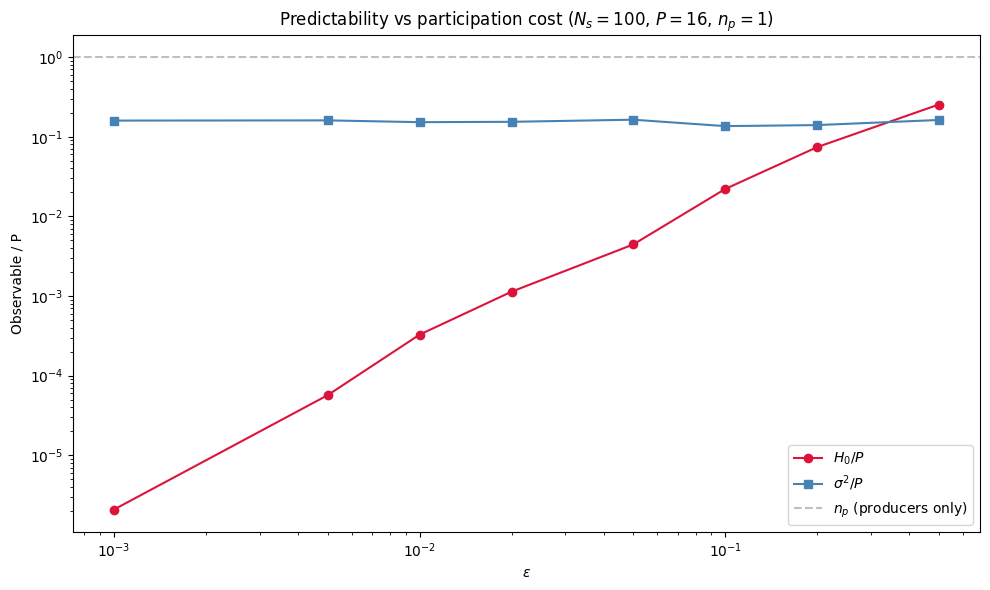

Min H_0/P = 0.000002 (at epsilon=0.001)
All H_0 > 0: True


In [5]:
# Parameters
P = 16
N_p = P
N_s = 100
n_realizations = 50

epsilon_values = np.array([0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5])
H0_eps = np.zeros(len(epsilon_values))
sigma2_eps = np.zeros(len(epsilon_values))

for i, eps in enumerate(tqdm(epsilon_values, desc="Scanning epsilon")):
    sigma2_eps[i], H0_eps[i] = measure_observables(N_s, P, N_p, eps, n_realizations)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epsilon_values, H0_eps / P, 'o-', color='crimson', label=r'$H_0 / P$')
ax.plot(epsilon_values, sigma2_eps / P, 's-', color='steelblue', label=r'$\sigma^2 / P$')
ax.axhline(y=N_p / P, color='gray', linestyle='--', alpha=0.5, label=r'$n_p$ (producers only)')
ax.set_xlabel(r'$\epsilon$')
ax.set_ylabel(r'Observable / P')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.set_title(f'Predictability vs participation cost ($N_s={N_s}$, $P={P}$, $n_p={N_p/P:.0f}$)')
plt.tight_layout()
plt.show()

print(f"Min H_0/P = {np.min(H0_eps/P):.6f} (at epsilon={epsilon_values[np.argmin(H0_eps/P)]})")
print(f"All H_0 > 0: {np.all(H0_eps > 0)}")

<blockquote>

We observe that $H_0 > 0$ for all tested values of $\epsilon > 0$, confirming that perfect efficiency ($H_0 = 0$) is impossible when $\epsilon > 0$.

We can also prove this by contradiction: 

Suppose $H_0 = 0$, i.e., $\langle A|\mu \rangle = 0$ for all $\mu$. Then there is no predictability in the market. Without predictability, speculator $i$'s expected gain per step is $\langle -a_i^{\mu} A \rangle = 0$, so the score update becomes $U_i(t+1) \approx U_i(t) - \epsilon$. Since $\epsilon > 0$, every agent's score decreases monotonically by $\epsilon$ per step. Eventually all agents satisfy $U_i < 0$, and $n_i = 0$ for all $i$.

Once all speculators exit, the excess demand reduces to $A(t) = \Omega^{\mu(t)}$, the pure producers' contribution. Since $\Omega^\mu \sim \mathcal{N}(0, N_p)$ and is generically nonzero, we get $\langle A|\mu \rangle = \Omega^\mu \neq 0$, hence $H_0 = \sum_\mu (\Omega^\mu)^2 / P = N_p > 0$. This contradicts the assumption $H_0 = 0$.

Therefore, $\epsilon > 0$ sets a floor on predictability: speculators only participate when their strategy is profitable enough (net of $\epsilon$), so they can never fully arbitrage away the producers' signal. The market reaches a self-consistent steady state where $0 < H_0 \leq N_p$.

</blockquote>

---
5. Tracer le vecteur $\Omega_{\mu}$ en regard du vecteur $\langle A|\mu\rangle$. Calculer une corrélation de Kendall. Commentez au regard de ce que vous savez de la dynamique de la prévisibilité.

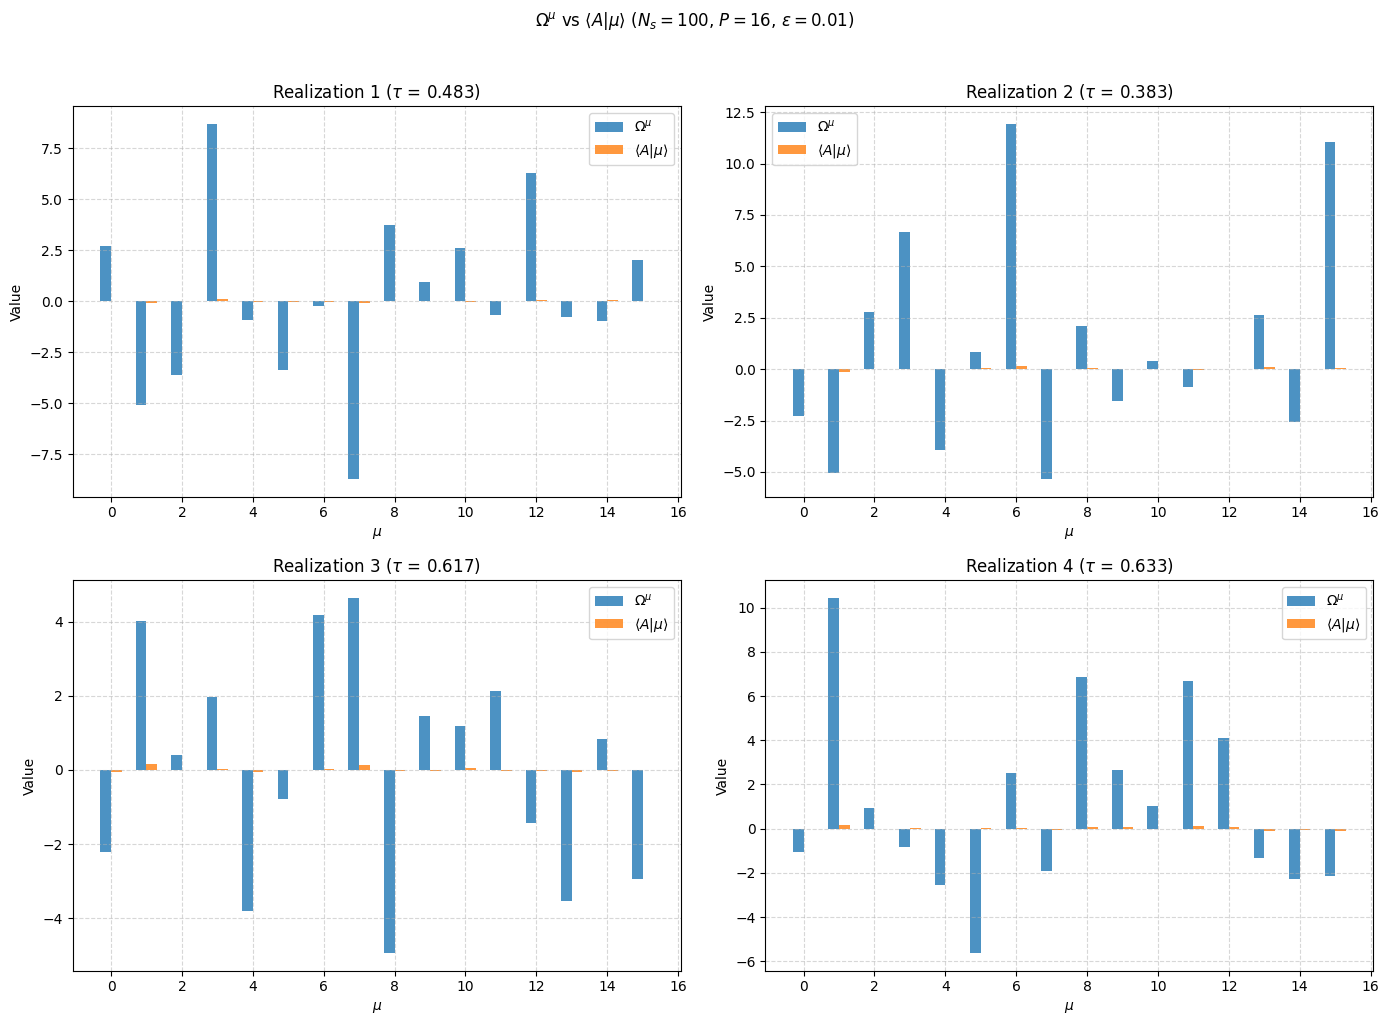

Kendall tau over 50 realizations:
    Mean = 0.5873
    Std  = 0.1035
    Min  = 0.3833
    Max  = 0.8500


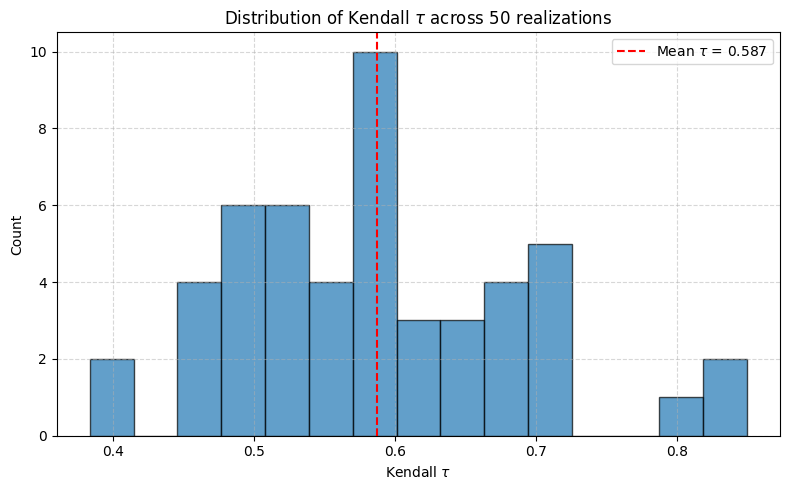

In [ ]:
# Parameters
P = 16
N_p = P
N_s = 100
epsilon = 0.01
n_realizations = 50
T_phase = int(200 * P / epsilon)

# Collect Omega and <A|mu> for each realization
tau_list = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for r in range(n_realizations):
    Omega = np.random.normal(0, np.sqrt(N_p), size=P)
    a = np.random.choice([-1, 1], size=(N_s, P)).astype(np.float64)
    U = np.zeros(N_s)
    mu = np.random.randint(0, P)

    # Transient
    _, _, U, mu = _run_simulation(a, Omega, U, mu, P, epsilon, T_phase)

    # Measurement
    A_meas, mu_meas, U, mu = _run_simulation(a, Omega, U, mu, P, epsilon, T_phase)

    # Conditional mean <A|mu>
    A_cond = np.zeros(P)
    for s in range(P):
        mask = (mu_meas == s)
        if np.any(mask):
            A_cond[s] = np.mean(A_meas[mask])

    tau, pval = kendalltau(Omega, A_cond)
    tau_list.append(tau)

    # Plot first 4 realizations as examples
    if r < 4:
        ax = axes[r // 2, r % 2]
        states = np.arange(P)
        ax.bar(states - 0.15, Omega, width=0.3, label=r'$\Omega^\mu$', alpha=0.8)
        ax.bar(states + 0.15, A_cond, width=0.3, label=r'$\langle A|\mu \rangle$', alpha=0.8)
        ax.set_xlabel(r'$\mu$')
        ax.set_ylabel('Value')
        ax.set_title(f'Realization {r+1} ($\\tau$ = {tau:.3f})')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle(f'$\\Omega^\\mu$ vs $\\langle A|\\mu \\rangle$ ($N_s={N_s}$, $P={P}$, $\\epsilon={epsilon}$)', y=1.02)
plt.tight_layout()
plt.show()

# Summary of Kendall correlations
tau_arr = np.array(tau_list)
print(f"Kendall tau over {n_realizations} realizations:")
print(f"    Mean = {np.mean(tau_arr):.4f}")
print(f"    Std  = {np.std(tau_arr):.4f}")
print(f"    Min  = {np.min(tau_arr):.4f}")
print(f"    Max  = {np.max(tau_arr):.4f}")

# Distribution of Kendall tau
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(tau_arr, bins=15, edgecolor='black', alpha=0.7)
ax.axvline(np.mean(tau_arr), color='red', linestyle='--', label=f'Mean $\\tau$ = {np.mean(tau_arr):.3f}')
ax.set_xlabel(r"Kendall $\tau$")
ax.set_ylabel("Count")
ax.set_title(f"Distribution of Kendall $\\tau$ across {n_realizations} realizations")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<blockquote>

The bar charts show that $\langle A|\mu \rangle$ consistently has the same sign as $\Omega^\mu$, though with a much smaller amplitude. The Kendall rank correlation is positive, with a mean $\tau \approx 0.60$ across 50 realizations.

This confirms that the residual predictability in the market is driven by the producers' signal $\Omega^\mu$. The speculators partially arbitrage away the producers' contribution but never fully eliminate it. In the stationary state, $\langle A|\mu \rangle$ is a damped copy of $\Omega^\mu$: the rank ordering is largely preserved (hence the high $\tau$), but the magnitude is reduced by the speculators' opposing trades.

This is consistent with the result from question 4. Since $\epsilon > 0$, speculators require a minimum profitability threshold to remain active. They exit when their score drops below zero, which happens before they can fully cancel out $\Omega^\mu$. The market thus retains a "memory" of the producers' signal in $\langle A|\mu \rangle$, and the Kendall correlation quantifies how faithfully this memory is preserved.

The correlation is not perfect ($\tau < 1$) because the speculators do not all target the same states equally: some states with large $|\Omega^\mu|$ attract more speculative activity than others, and the nonlinear participation dynamics (via the Heaviside function) introduce state-dependent corrections to the ranking.

</blockquote>

---
6. Prendre $a_{i,\mu}\sim P(a)$ où $P(a)$ est telle que $E(a)=0$ et $E(a^{2})=1$. Refaire le point 3. Voyez-vous des différences perceptibles ?

Scanning N_s: 100%|██████████| 12/12 [11:00<00:00, 55.07s/it] 


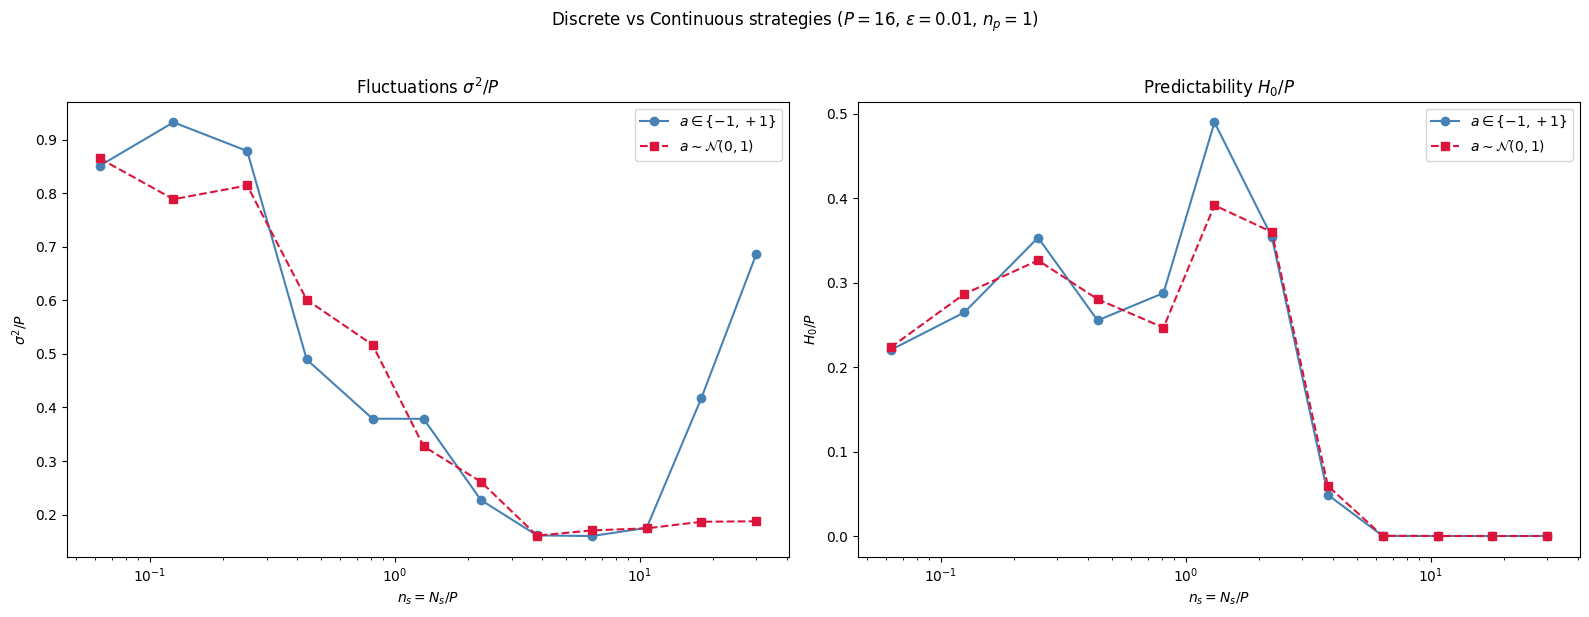

In [7]:
def measure_observables_both(N_s, P, N_p, epsilon, n_realizations=50):
    """Run both discrete and continuous strategy distributions in one pass."""
    T_phase = int(200 * P / epsilon)
    sigma2_disc = np.zeros(n_realizations)
    H0_disc = np.zeros(n_realizations)
    sigma2_cont = np.zeros(n_realizations)
    H0_cont = np.zeros(n_realizations)

    for r in range(n_realizations):
        Omega = np.random.normal(0, np.sqrt(N_p), size=P)
        mu0 = np.random.randint(0, P)

        for kind in range(2):
            if kind == 0:
                a = np.random.choice([-1, 1], size=(N_s, P)).astype(np.float64)
            else:
                a = np.random.normal(0, 1, size=(N_s, P))
            U = np.zeros(N_s)
            mu = mu0

            _, _, U, mu = _run_simulation(a, Omega, U, mu, P, epsilon, T_phase)
            A_meas, mu_meas, U, mu = _run_simulation(a, Omega, U, mu, P, epsilon, T_phase)

            s2 = np.mean(A_meas**2)
            H0 = 0.0
            for s in range(P):
                mask = (mu_meas == s)
                if np.any(mask):
                    H0 += np.mean(A_meas[mask])**2
            H0 /= P

            if kind == 0:
                sigma2_disc[r], H0_disc[r] = s2, H0
            else:
                sigma2_cont[r], H0_cont[r] = s2, H0

    return (np.mean(sigma2_disc), np.mean(H0_disc),
            np.mean(sigma2_cont), np.mean(H0_cont))

# Parameters
P = 16
N_p = P
epsilon = 0.01
n_realizations = 50

N_s_values = np.unique(np.logspace(np.log10(1), np.log10(30 * P), 13).astype(int))
n_s_values = N_s_values / P

sigma2_disc_arr = np.zeros(len(N_s_values))
H0_disc_arr = np.zeros(len(N_s_values))
sigma2_cont_arr = np.zeros(len(N_s_values))
H0_cont_arr = np.zeros(len(N_s_values))

for i, N_s in enumerate(tqdm(N_s_values, desc="Scanning N_s")):
    s2d, h0d, s2c, h0c = measure_observables_both(int(N_s), P, N_p, epsilon, n_realizations)
    sigma2_disc_arr[i], H0_disc_arr[i] = s2d, h0d
    sigma2_cont_arr[i], H0_cont_arr[i] = s2c, h0c

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(n_s_values, sigma2_disc_arr / P, 'o-', label=r'$a \in \{-1,+1\}$', color='steelblue')
ax.plot(n_s_values, sigma2_cont_arr / P, 's--', label=r'$a \sim \mathcal{N}(0,1)$', color='crimson')
ax.set_xlabel(r'$n_s = N_s / P$')
ax.set_ylabel(r'$\sigma^2 / P$')
ax.set_xscale('log')
ax.legend()
ax.set_title(r'Fluctuations $\sigma^2 / P$')

ax = axes[1]
ax.plot(n_s_values, H0_disc_arr / P, 'o-', label=r'$a \in \{-1,+1\}$', color='steelblue')
ax.plot(n_s_values, H0_cont_arr / P, 's--', label=r'$a \sim \mathcal{N}(0,1)$', color='crimson')
ax.set_xlabel(r'$n_s = N_s / P$')
ax.set_ylabel(r'$H_0 / P$')
ax.set_xscale('log')
ax.legend()
ax.set_title(r'Predictability $H_0 / P$')

plt.suptitle(f'Discrete vs Continuous strategies ($P={P}$, $\\epsilon={epsilon}$, $n_p={N_p/P:.0f}$)', y=1.02)
plt.tight_layout()
plt.show()

<blockquote>

The two distributions yield similar results. The two curves for $\sigma^2/P$ and $H_0/P$ overlap across the moderate-density regime of $n_s$, but finite-size corrections appear at large $n_s$. Both distributions show the same qualitative regimes: a decrease in fluctuations toward a minimum around $n_s \approx 7$, followed by a linear growth at large $n_s$ for $\sigma^2/P$ but only for the Rademacher distribution and not the Gaussian distribution, while the predictability $H_0/P$ peaks near $n_s \approx 1$ and decays to zero at large $n_s$.

The difference in the behavior of $\sigma^2/P$ at large $n_s$ between the two distributions is possibly due to the finite number of realizations. Universality holds asymptotically as $N_s, P \to \infty$ at fixed $N_s/P$, but at $P=16$ and finite $N_s$, fluctuations are non-negligible nd can amplify differences in the distributions that would vanish at the limit.

This is expected from the theory. The macroscopic observables $\sigma^2$ and $H_0$ depend on the strategy matrix $a$ only through the covariance structure: $\langle a_{i,\mu} \rangle = 0$ and $\langle a_{i,\mu}^2 \rangle = 1$. Both the Rademacher distribution ($a \in \{-1,+1\}$) and the standard normal ($a \sim \mathcal{N}(0,1)$) satisfy these constraints. Since the number of agents $N_s$ and the number of states $P$ are large enough for the law of large numbers to apply, the aggregate excess demand $A(t) = \Omega^\mu + \sum_i n_i a_{i,\mu}$ has the same statistical properties in both cases. The universality of the minority game is confirmed: the macroscopic behavior depends on the first two moments of $P(a)$, not on the detailed shape of the distribution.

</blockquote>